## Figures Calcul 001

In [1]:
# import necessary libraries
import csv
import numpy as np
import matplotlib.pyplot as plt
import re

### 1. Reading the data file and extracting metadata from the header

In [2]:
# File paths
data_path = "../data/001MoDe_R1.csv"
marker_path = "../data/001MoDe_R1.marker.csv"

# Read header from data file
header = {}
with open(data_path, "r", encoding="utf-8") as f:
    first = ""
    while True:
        line = f.readline()
        if not line:
            break
        line = line.strip()
        if line:
            first = line
            break
# parse header line
if first:
    for part in first.split(";"):
        part = part.strip()
        if not part:
            continue
        if "=" in part:
            k, v = part.split("=", 1)
        elif ":" in part:
            k, v = part.split(":", 1)
        else:
            tokens = part.split()
            k = tokens[0]
            v = tokens[1] if len(tokens) > 1 else ""
            k = k.strip()
            v = v.strip()
        k = k.strip()
        v = v.strip()
# attempt to convert to float
        try:
            header[k] = float(v)
        except Exception:
            header[k] = v

# print a few header fields like in expected output
for key in ("screenWidth","screenHeight","cornerX","cornerY","centerX","centerY",
            "externalRadius","internalRadius","borderRadius","cursorRadius",
            "indexOfDifficulty","taskRadius","taskTolerance","autoStart",
            "cycleMaxNumber","cycleDuration","software","version","task","isWithLSL",
            "borderColor","backgroundColor","cursorColorRecord","cursorColorWait"):
    if key in header:
        print(f"{key}: {header[key]}")

screenWidth: 1104.0
screenHeight: 661.0
cornerX: 302.0
cornerY: 80.0
centerX: 552.0
centerY: 330.0
externalRadius: 250.0
internalRadius: 170.0
borderRadius: 1.0
cursorRadius: 16.0
indexOfDifficulty: 28.00696429476858
taskRadius: 209.5
taskTolerance: 47.0
autoStart: 3600.0
cycleMaxNumber: 6.0
cycleDuration: 20.0
software: LSL-mouse
version: 1.2.0rc5
task: CircularTarget
isWithLSL: false


### 2. Extracting start and end timestamps from the marker file

In [3]:
# read marker file and extract record start/end times
lines = open(marker_path, "r", encoding="utf-8").read().splitlines()

record_start_raw = []
record_end_raw = []
all_markers = []  # (ts, text)

for line in lines:
    parts = line.strip().split(",")
    # need at least 2 columns (date, timestamp)
    if len(parts) < 2:
        continue
    ts_str = parts[1].strip()
    # normalize numeric characters
    ts_str = ts_str.replace(" ", "")
    try:
        ts = int(ts_str)
    except Exception:
        # skip non-timestamp marker lines (or summary lines)
        continue
    txt = line.strip()
    all_markers.append((ts, txt))
    if "DoCycleChange:DoRecord" in line:
        record_start_raw.append(ts)
    elif "DoCycleChange:DoPause" in line:
        record_end_raw.append(ts)

if not record_start_raw or not record_end_raw:
    raise ValueError("Aucun événement 'DoRecord' / 'DoPause' détecté dans le fichier .marker.csv")

# sort timestamps (defensive)
record_start_raw.sort()
record_end_raw.sort()

# pair start/end timestamps
pairs = []
ei = 0
for s in record_start_raw:
    # advance end index until find end >= s
    while ei < len(record_end_raw) and record_end_raw[ei] < s:
        ei += 1
    if ei < len(record_end_raw):
        pairs.append((s, record_end_raw[ei]))
        ei += 1
    else:
        # unmatched start: break/ignore
        break

if not pairs:
    raise RuntimeError("Aucun couple start/end valide trouvé dans les marqueurs.")

# determine origin timestamp (t0)
def _first_data_timestamp(path):
    with open(path, "r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            # data rows are like "t,x,y" or the CSV first cell contains "t,x,y"
            # attempt to find first numeric token
            # split on ';' then check first cell for comma form
            cells = ln.split(";")
            cell0 = cells[0].strip()
            if "," in cell0:
                p = [s.strip() for s in cell0.split(",")]
                if p and re.match(r"^-?\d+(\.\d+)?$", p[0].replace(",", ".")):
                    try:
                        return float(p[0])
                    except Exception:
                        continue
            # fallback: if comma-separated row (no semicolon)
            if "," in ln:
                p = [s.strip() for s in ln.split(",")]
                if p and re.match(r"^-?\d+(\.\d+)?$", p[0].replace(",", ".")):
                    try:
                        return float(p[0])
                    except Exception:
                        continue
    return None

t0_data = _first_data_timestamp(data_path)
# prefer data timestamp origin if available, else use first DoRecord timestamp
if t0_data is not None:
    # data timestamps are in ms, keep integer origin
    t0 = int(round(t0_data))
else:
    t0 = pairs[0][0]

# print record start/end times in both
print("\nrecord times (milliseconds since the Unix epoch):")
for s, e in pairs:
    dur_ms = e - s
    print(f"{s} to {e} ({dur_ms/1000.0:.3f} s)")

print("\nrecord times (seconds since the first origin):")
record_start_sec = [ (s - t0)/1000.0 for s, _ in pairs ]
record_end_sec  = [ (e - t0)/1000.0 for _, e in pairs ]
for s_sec, e_sec in zip(record_start_sec, record_end_sec):
    print(f"{s_sec:6.3f} to {e_sec:6.3f} ({e_sec - s_sec:6.3f} s)")

# optional: print full marker lines (timestamp : text) like expected listing
print(f"\nMarkers in '{marker_path}':")
for ts, txt in all_markers:
    payload = txt.split(",", 2)[-1].strip()
    print(f"{ts}: {payload}")


record times (milliseconds since the Unix epoch):
1616776712333 to 1616776732336 (20.003 s)
1616776752340 to 1616776772351 (20.011 s)
1616776792372 to 1616776812386 (20.014 s)
1616776832390 to 1616776852404 (20.014 s)
1616776872419 to 1616776892433 (20.014 s)

record times (seconds since the first origin):
 0.004 to 20.007 (20.003 s)
40.011 to 60.022 (20.011 s)
80.043 to 100.057 (20.014 s)
120.061 to 140.075 (20.014 s)
160.090 to 180.104 (20.014 s)

Markers in '../data/001MoDe_R1.marker.csv':
1616776712325: KeyTyped=32 DoCycleChange
1616776712331: DoCycleChange:DoStartCycleTimedSequence
1616776712333: DoCycleChange:DoRecord RecordDone=0 PauseDone=0 ToDo=6
1616776732336: DoCycleChange:DoPause RecordDone=1 PauseDone=0 ToDo=6
1616776752340: DoCycleChange:DoRecord RecordDone=1 PauseDone=1 ToDo=6
1616776772351: DoCycleChange:DoPause RecordDone=2 PauseDone=1 ToDo=6
1616776792372: DoCycleChange:DoRecord RecordDone=2 PauseDone=2 ToDo=6
1616776812386: DoCycleChange:DoPause RecordDone=3 PauseDo

### 3. Define variables from header for later use 

In [4]:

screenWidth  = header.get("screenWidth") 
screenHeight = header.get("screenHeight")
centerX      = header.get("centerX")
centerY      = header.get("centerY")
cornerX      = header.get("cornerX")
cornerY      = header.get("cornerY")
externalRadius = header.get("externalRadius")
internalRadius = header.get("internalRadius")
borderRadius   = header.get("borderRadius")
cursorRadius   = header.get("cursorRadius")
indexOfDifficulty = header.get("indexOfDifficulty")
taskRadius      = header.get("taskRadius")
tasktolerance   = header.get("taskTolerance")
autoStart      = header.get("autoStart")
cycleMaxNumber = header.get("cycleMaxNumber")
cycleDuration  = header.get("cycleDuration")

### 4. Loading the data file (t, x, y, in_target) and array conversion

In [5]:
timestamps, mouseX, mouseY, in_target = [], [], [], []

with open(data_path, "r") as f:
    reader = csv.reader(f, delimiter=';')  # ou ',' selon ton fichier
    rows = list(reader)

for r in rows:
    if len(r) >= 1 and ',' in r[0]:
        parts = r[0].split(',')
        if len(parts) >= 4:  # timestamp, X, Y, in_target
            try:
                t = float(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                flag = int(float(parts[3]))  # 1 ou 0
                timestamps.append(t)
                mouseX.append(x)
                mouseY.append(y)
                in_target.append(flag)
            except ValueError:
                continue

# array conversion
timestamps = np.array(timestamps)
mouseX = np.array(mouseX)
mouseY = np.array(mouseY)
in_target = np.array(in_target)

### 5. Computing normalized time vectors

In [6]:
# Time conversion (seconds)
time = (timestamps - timestamps[0]) / 1000.0

# Time normalization based on record start/end
t0 = min(record_start_raw + record_end_raw)
record_start_sec = [(t - t0) / 1000.0 for t in record_start_raw]
record_end_sec  = [(t - t0) / 1000.0 for t in record_end_raw]

### 6. Processing marker events and duration extraction

In [7]:
def compute_task_duration(marker_path, record_start_sec, record_end_sec):

    # Read marker file again for processing
    with open(marker_path, "r") as f:
        lines = f.readlines()

    record_start_raw, record_end_raw, timestamp_all = [], [], []

    # Timestamp extraction
    for line in lines:
        parts = line.strip().split(",")
        if len(parts) < 3:
            continue
        try:
            ts = int(parts[1])
            timestamp_all.append(ts)
        except ValueError:
            continue

        if "DoCycleChange:DoRecord" in line:
            record_start_raw.append(ts)
        elif "DoCycleChange:DoPause" in line:
            record_end_raw.append(ts)

    # Verifications
    if len(record_start_raw) == 0:
        raise ValueError("No ‘DoRecord’ event detected in the file.")
    if len(record_end_raw) == 0:
        raise ValueError("No ‘DoPause’ event detected in the file.")
    if len(record_start_raw) != len(record_end_raw):
        print("Number of starts and ends does not match.")

    # Duration calculation for each task
    task_durations = []
    for start, end in zip(record_start_sec, record_end_sec):
        duration = end - start
        task_durations.append(duration)

    # Output results
    print("Start times (s):", record_start_sec)
    print("End times (s):", record_end_sec)
    print("Duration (s):", task_durations)

    # Detailed summary
    print("\nSummary:")
    for i, (start, end, dur) in enumerate(zip(record_start_sec, record_end_sec, task_durations), start=1):
        print(f"Task {i}: start = {start:.2f}s, end = {end:.2f}s, duration = {dur:.2f}s")

    return

compute_task_duration(marker_path, record_start_sec, record_end_sec)


Start times (s): [0.0, 40.007, 80.039, 120.057, 160.086]
End times (s): [20.003, 60.018, 100.053, 140.071, 180.1]
Duration (s): [20.003, 20.011000000000003, 20.013999999999996, 20.013999999999996, 20.01399999999998]

Summary:
Task 1: start = 0.00s, end = 20.00s, duration = 20.00s
Task 2: start = 40.01s, end = 60.02s, duration = 20.01s
Task 3: start = 80.04s, end = 100.05s, duration = 20.01s
Task 4: start = 120.06s, end = 140.07s, duration = 20.01s
Task 5: start = 160.09s, end = 180.10s, duration = 20.01s


### 7. Preprocessing and record-by-record visualization

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


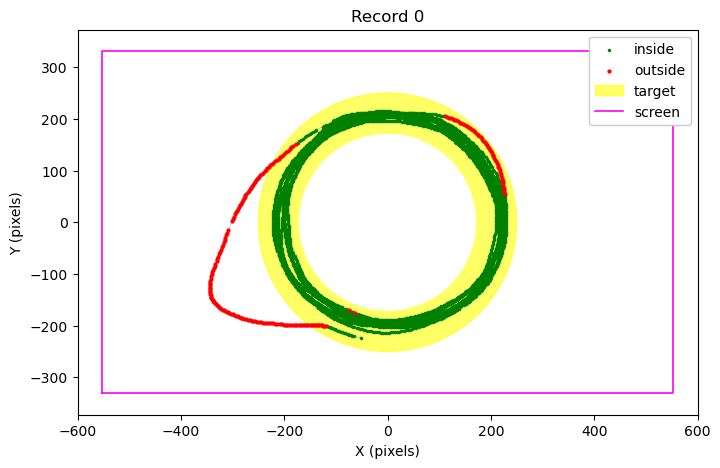

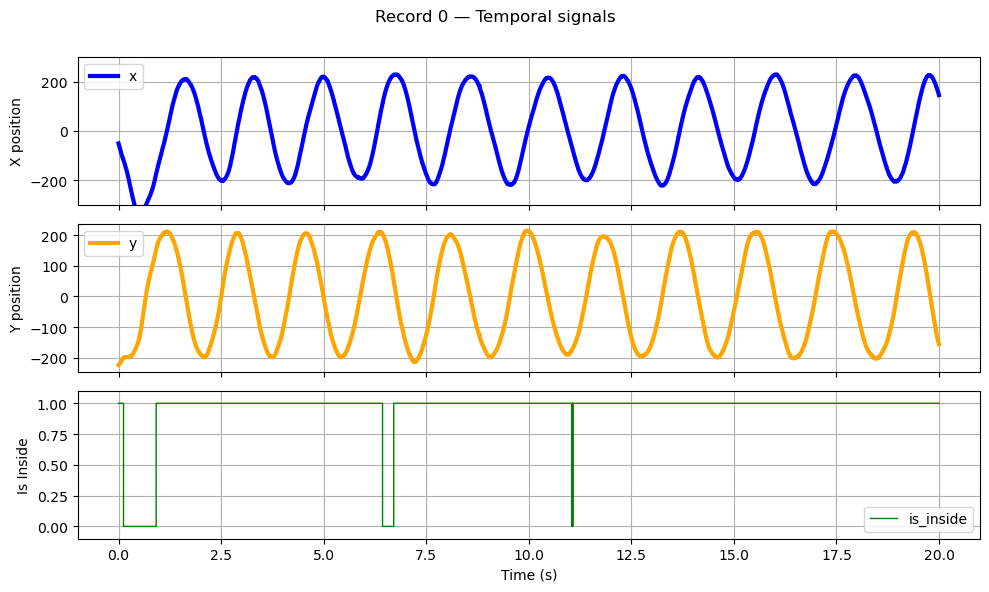

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


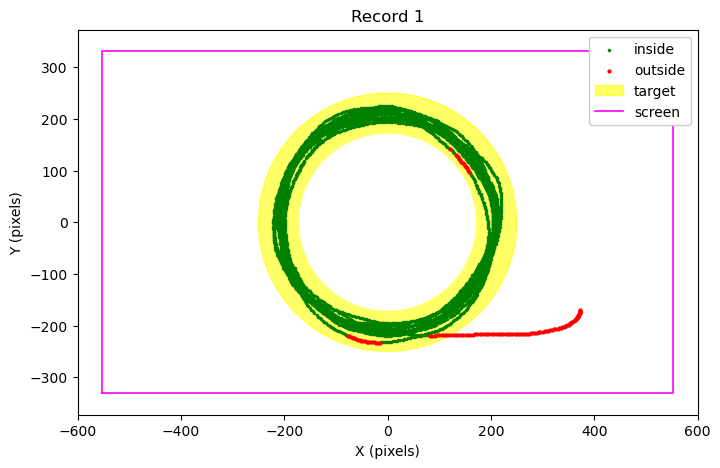

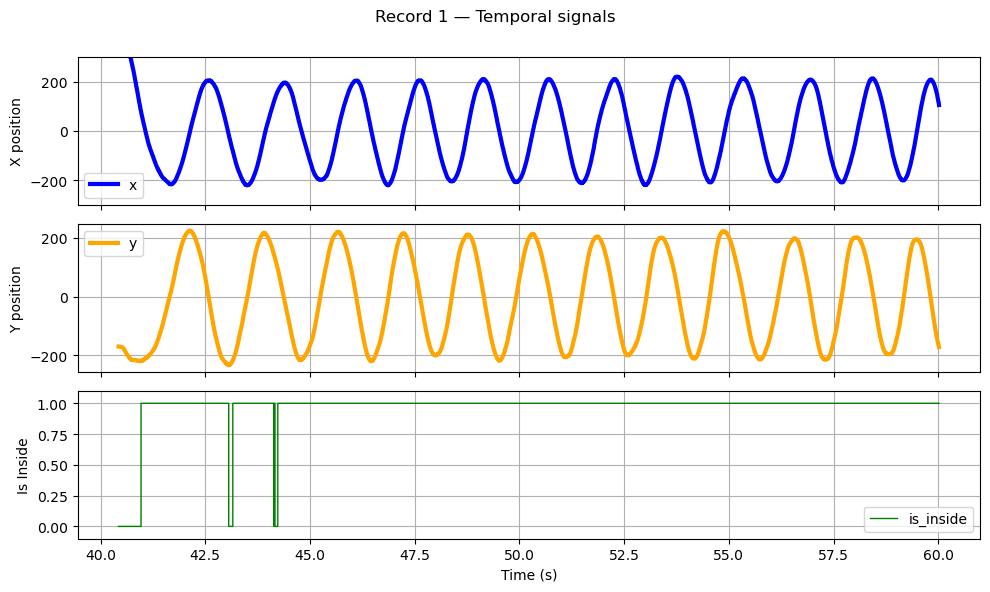

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


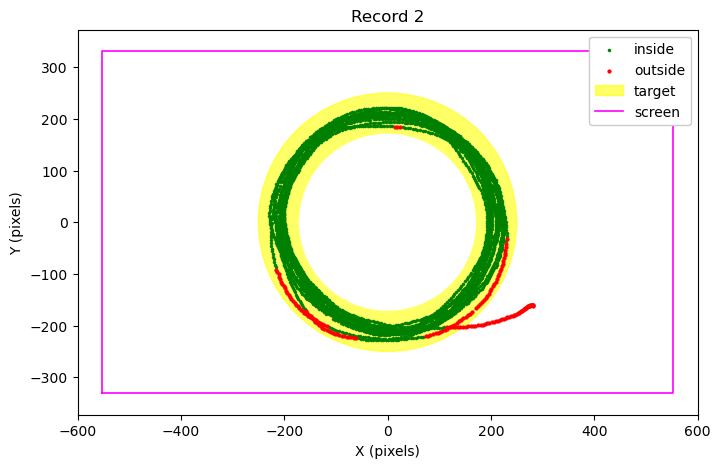

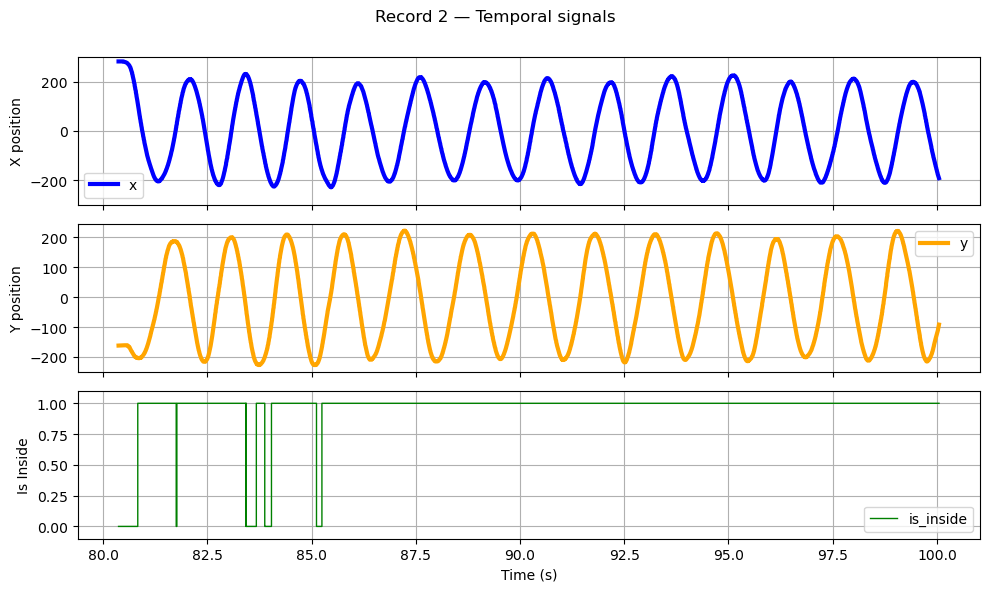

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


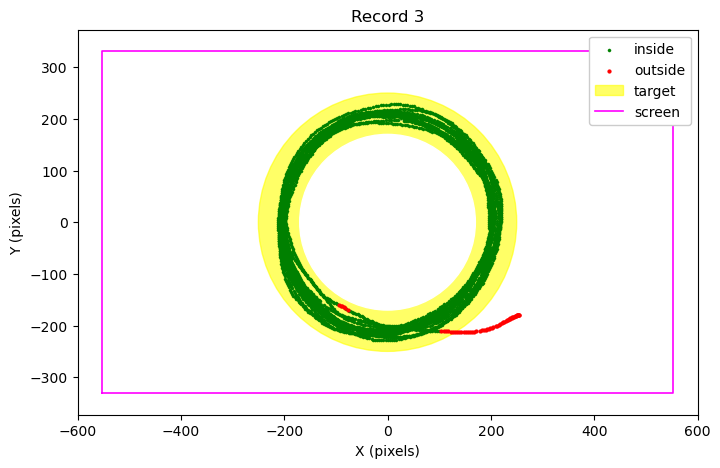

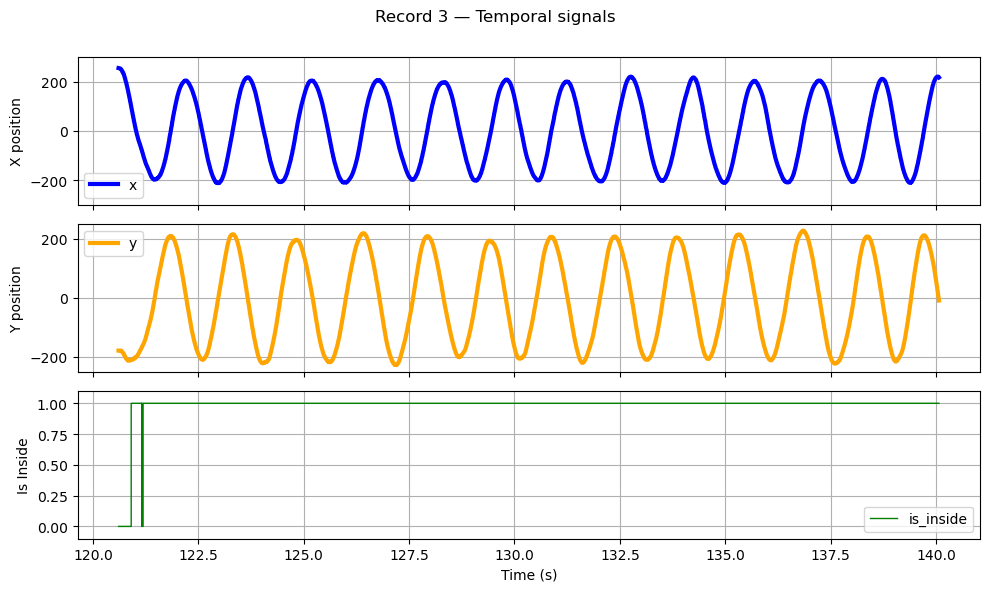

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


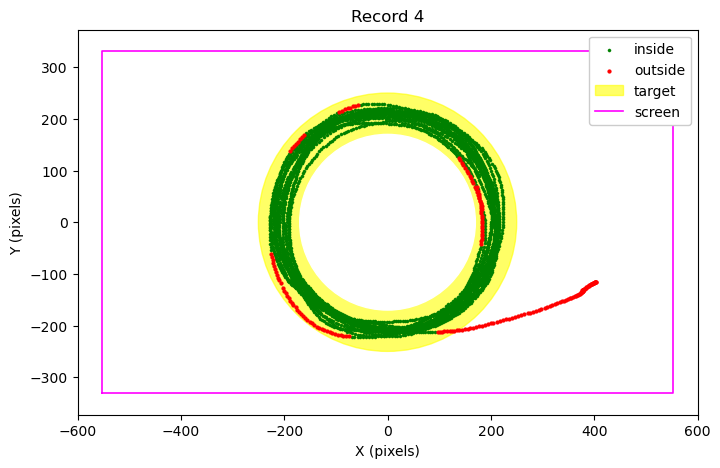

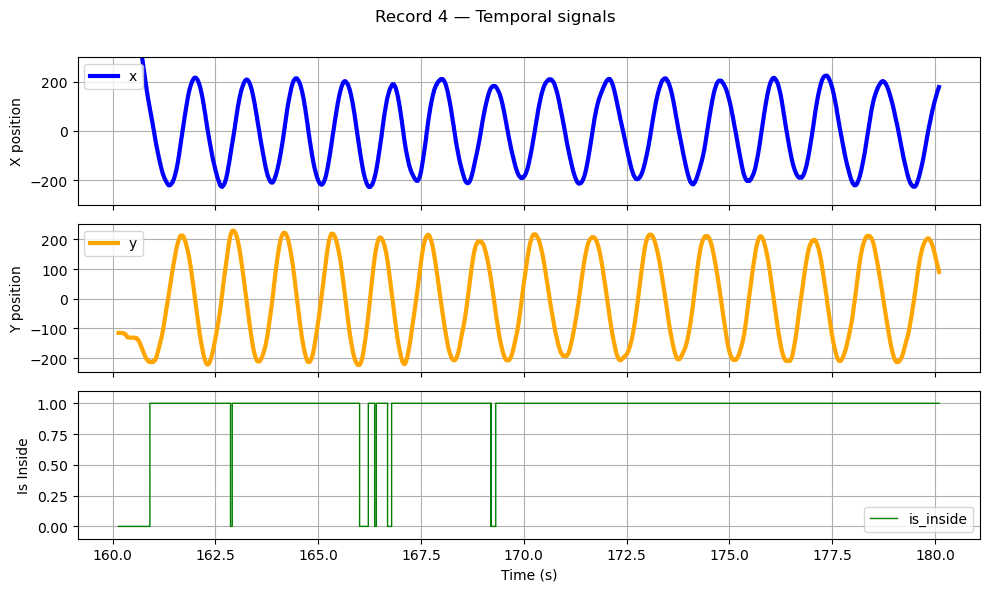

In [8]:
# Normalization of lengths to avoid error
m = min(len(time), len(mouseX), len(mouseY), len(in_target))
time = time[:m]
mouseX = mouseX[:m]
mouseY = mouseY[:m]
in_target = in_target[:m]

# Principal loop over records
records_data = []

for i, (start, end) in enumerate(zip(record_start_sec, record_end_sec), start=0):
    mask = (time >= start) & (time <= end)
    x_task = mouseX[mask] - centerX
    y_task = -(mouseY[mask] - centerY)
    t_task = time[mask]
    in_task = in_target[mask]

    records_data.append({
        "record": i,
        "time": t_task,
        "x": x_task,
        "y": y_task,
        "in_target": in_task
    })

    # ======================================================
    # Spatial plot (trajectory + target)
    # ======================================================
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(x_task, y_task, '-', color='steelblue', label=None, zorder=2, lw=0.2)
    ax1.scatter(x_task[in_task == 1], y_task[in_task == 1],
                color='green', s=5, label='inside', zorder=3, lw=0.3)
    ax1.scatter(x_task[in_task == 0], y_task[in_task == 0],
                color='red', s=5, label='outside', zorder=3, lw=0.8)

    # Target (ring)
    circle_outer = plt.Circle((0, 0), externalRadius, color='yellow', alpha=0.6, zorder=1, label='target')
    circle_inner = plt.Circle((0, 0), internalRadius, color='white', zorder=2)
    ax1.add_patch(circle_outer)
    ax1.add_patch(circle_inner)

    # Screen border
    ax1.plot([-screenWidth/2, screenWidth/2, screenWidth/2, -screenWidth/2, -screenWidth/2],
             [-screenHeight/2, -screenHeight/2, screenHeight/2, screenHeight/2, -screenHeight/2],
             color='magenta', lw=1.2, label='screen', zorder=0)

    ax1.set_title(f"Record {i}")
    ax1.set_xlabel("X (pixels)")
    ax1.set_ylabel("Y (pixels)")
    ax1.axis("equal")
    ax1.set_xlim(-600, 600)
    ax1.set_ylim(-400, 400)
    ax1.legend(loc='upper right', framealpha=1, facecolor='white')
    ax1.grid(False)
    plt.show()

    # ======================================================
    # Temporal plot (X, Y, Inside)
    # ======================================================
    fig2, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig2.suptitle(f"Record {i} — Temporal signals")

    # X
    axes[0].plot(t_task, x_task, color='blue', label='x', lw=3)
    axes[0].set_ylabel("X position")
    axes[0].set_ylim(-300, 300)
    axes[0].legend()
    axes[0].grid(True)

    # Y
    axes[1].plot(t_task, y_task, color='orange', label='y', lw=3)
    axes[1].set_ylabel("Y position")
    axes[0].set_ylim(-300, 300)
    axes[1].legend()
    axes[1].grid(True)

    # Inside
    axes[2].step(t_task, in_task, where='post', color='green', label='is_inside', lw=1)
    axes[2].set_ylabel("Is Inside")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()


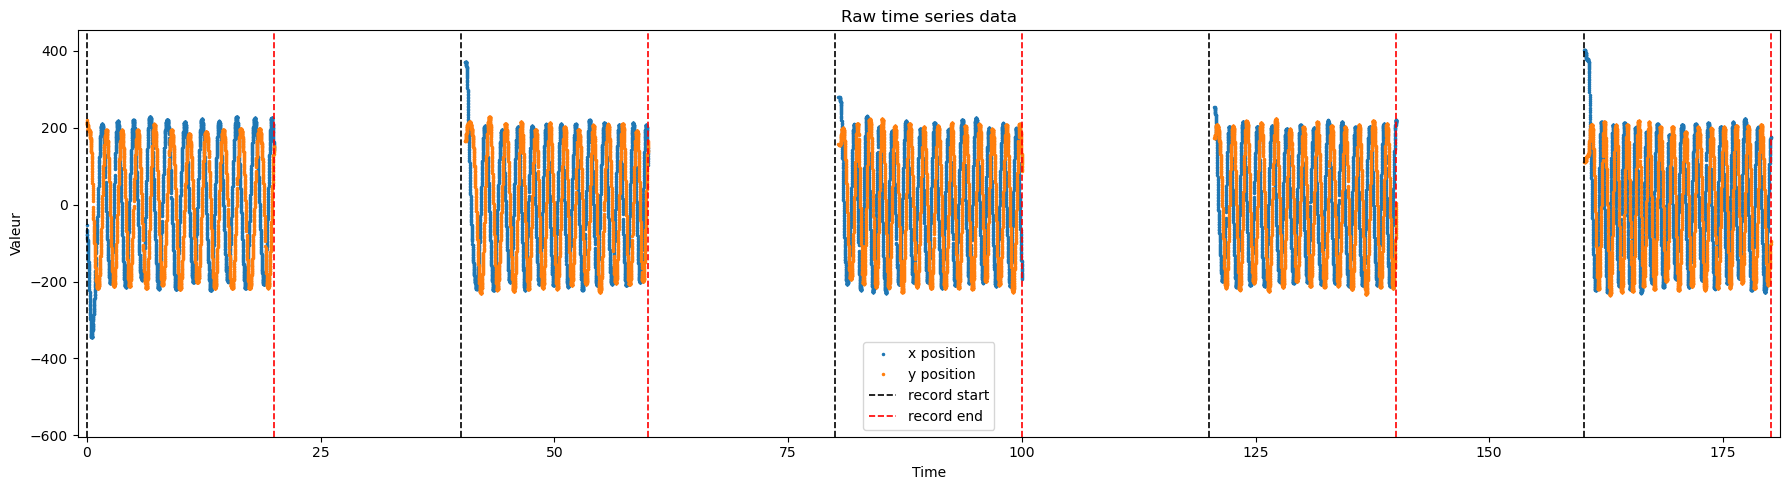

In [9]:
# --- Tes données existantes ---
# time, in_target sont déjà définis
record_start_sec = [0.0, 40.007, 80.039, 120.057, 160.086]
record_end_sec  = [20.003, 60.018, 100.053, 140.071, 180.1]

# --- Création des 5 graphes ---
plt.figure(figsize=(18, 5))

# --- Tracé des positions centrées (points pour lisibilité fine) ---
plt.plot(time, mouseX - np.mean(mouseX), '.', ms=3, color='tab:blue', label='x position')
plt.plot(time, mouseY - np.mean(mouseY), '.', ms=3, color='tab:orange', label='y position')

# --- Marqueurs de début et fin d’enregistrement ---
for s in record_start_sec:
    plt.axvline(s, color='black', linestyle='--', linewidth=1.2, label='record start' if s == record_start_sec[0] else "")
for e in record_end_sec:
    plt.axvline(e, color='red', linestyle='--', linewidth=1.2, label='record end' if e == record_end_sec[0] else "")

# --- Ajustements visuels ---
plt.xlim(min(time[0], record_start_sec[0]) - 1, max(time[-1], record_end_sec[-1]) + 1)
plt.ylim(np.min([mouseX - np.mean(mouseX), mouseY - np.mean(mouseY)]) - 50, np.max([mouseX - np.mean(mouseX), mouseY - np.mean(mouseY)]) + 50)

plt.xlabel("Time")
plt.ylabel("Valeur")
plt.title("Raw time series data")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()